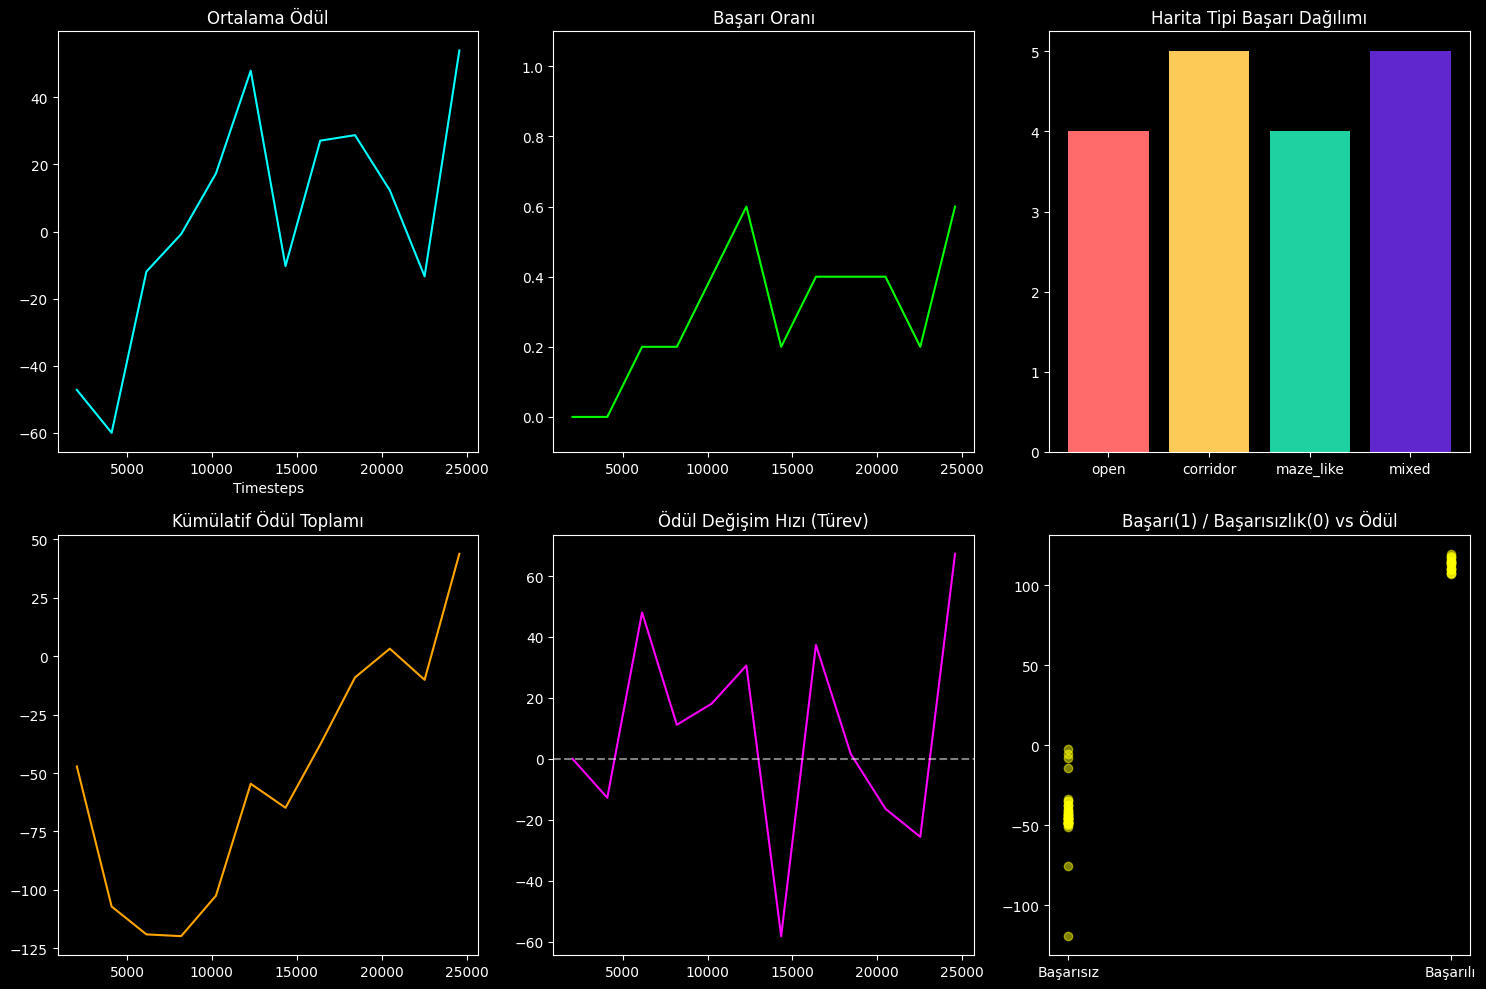

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


KeyboardInterrupt: 

In [ ]:
!pip install stable-baselines3 gymnasium matplotlib numpy -q

import os
import time
import math
import random
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from matplotlib.backends.backend_agg import FigureCanvasAgg
import matplotlib.patches as patches
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import DummyVecEnv
from IPython.display import clear_output, display
from collections import deque

# ==========================================
# 1. DİNAMİK ENGEL SINIFI
# ==========================================
class DynamicObstacle:
    def __init__(self, x, y, vx, vy, grid_size):
        self.x = float(x)
        self.y = float(y)
        self.vx = float(vx)
        self.vy = float(vy)
        self.grid_size = grid_size
        self.max_speed = max(abs(self.vx), abs(self.vy), 1e-5)

    def step(self):
        self.x += self.vx
        self.y += self.vy

        if self.x < 0:
            self.x = -self.x
            self.vx = -self.vx
        elif self.x >= self.grid_size - 1:
            self.x = 2 * (self.grid_size - 1) - self.x
            self.vx = -self.vx

        if self.y < 0:
            self.y = -self.y
            self.vy = -self.vy
        elif self.y >= self.grid_size - 1:
            self.y = 2 * (self.grid_size - 1) - self.y
            self.vy = -self.vy

    @property
    def grid_pos(self):
        return (int(round(self.x)), int(round(self.y)))

    def normalized_velocity(self, max_speed_override=None):
        speed_scale = max_speed_override if max_speed_override else self.max_speed
        return (self.vx / speed_scale, self.vy / speed_scale)


# ==========================================
# 2. PROCEDURAL HARİTA ÜRETİMİ
# ==========================================
class MapGenerator:
    def __init__(self, grid_size, n_static):
        self.grid_size = grid_size
        self.n_static = n_static

    def generate(self, map_type=None):
        templates = ["open", "corridor", "maze_like", "mixed"]
        if map_type is None or map_type not in templates:
            map_type = random.choice(templates)

        static_obstacles = set()

        if map_type == "open":
            while len(static_obstacles) < self.n_static:
                static_obstacles.add((random.randint(0, self.grid_size-1), random.randint(0, self.grid_size-1)))

        elif map_type == "corridor":
            lines = self.n_static // (self.grid_size // 2)
            for _ in range(lines):
                is_horizontal = random.choice([True, False])
                fixed = random.randint(1, self.grid_size-2)
                start = random.randint(0, self.grid_size // 2)
                for i in range(start, min(start + self.grid_size // 2, self.grid_size)):
                    if random.random() > 0.2:
                        if is_horizontal: static_obstacles.add((i, fixed))
                        else: static_obstacles.add((fixed, i))

        elif map_type == "maze_like":
            segments = self.n_static // 3
            for _ in range(segments):
                x, y = random.randint(1, self.grid_size-2), random.randint(1, self.grid_size-2)
                dx, dy = random.choice([(1,0), (0,1), (-1,0), (0,-1)])
                for step in range(3):
                    nx, ny = x + dx*step, y + dy*step
                    if 0 <= nx < self.grid_size and 0 <= ny < self.grid_size:
                        static_obstacles.add((nx, ny))

        elif map_type == "mixed":
            while len(static_obstacles) < self.n_static // 2:
                static_obstacles.add((random.randint(0, self.grid_size-1), random.randint(0, self.grid_size-1)))
            x, y = random.randint(1, self.grid_size-2), random.randint(1, self.grid_size-2)
            for step in range(self.n_static // 2):
                static_obstacles.add((x, y))
                dx, dy = random.choice([(1,0), (0,1), (-1,0), (0,-1)])
                x = max(0, min(self.grid_size-1, x+dx))
                y = max(0, min(self.grid_size-1, y+dy))

        return static_obstacles, map_type

    def get_start_and_goal(self, static_obstacles):
        min_dist = self.grid_size * 0.4
        while True:
            start = (random.randint(0, self.grid_size-1), random.randint(0, self.grid_size-1))
            goal = (random.randint(0, self.grid_size-1), random.randint(0, self.grid_size-1))
            if start not in static_obstacles and goal not in static_obstacles and start != goal:
                dist = math.hypot(start[0]-goal[0], start[1]-goal[1])
                if dist >= min_dist:
                    return start, goal


# ==========================================
# 3. ORTAM (gymnasium.Env Subclass) - ZORLU KURALLAR
# ==========================================
class AutonomousDriverEnv(gym.Env):
    metadata = {"render_modes": ["rgb_array"], "render_fps": 10}

    def __init__(self, grid_size=12, n_static=4, n_dynamic=0, max_steps=150, view_radius=7, render_mode=None):
        super(AutonomousDriverEnv, self).__init__()

        self.grid_size = grid_size
        self.n_static = n_static
        self.n_dynamic = n_dynamic
        self.max_steps = max_steps
        self.view_radius = view_radius
        self.render_mode = render_mode
        self.map_gen = MapGenerator(grid_size, n_static)

        self.action_space = spaces.Discrete(5)
        self.observation_space = spaces.Box(low=-1.0, high=1.0, shape=(102,), dtype=np.float32)

        self.agent_pos = None
        self.goal_pos = None
        self.static_obs = set()
        self.dynamic_obs = []
        self.visit_map = None
        self.action_history = None
        self.steps = 0
        self.prev_dist = 0
        self.map_type_current = ""
        self.agent_trajectory = []

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.static_obs, self.map_type_current = self.map_gen.generate()
        self.agent_pos, self.goal_pos = self.map_gen.get_start_and_goal(self.static_obs)
        self.agent_trajectory = [self.agent_pos]

        self.dynamic_obs = []
        for _ in range(self.n_dynamic):
            while True:
                dx = random.randint(0, self.grid_size-1)
                dy = random.randint(0, self.grid_size-1)
                if (dx, dy) not in self.static_obs and (dx, dy) != self.agent_pos and (dx, dy) != self.goal_pos:
                    # YALNIZCA YATAY VEYA DİKEY HAREKET (Sabit Hız: 0.5)
                    speed = 0.5
                    if random.choice([True, False]):
                        vx = random.choice([-speed, speed])
                        vy = 0.0
                    else:
                        vx = 0.0
                        vy = random.choice([-speed, speed])

                    self.dynamic_obs.append(DynamicObstacle(dx, dy, vx, vy, self.grid_size))
                    break

        self.visit_map = np.zeros((self.grid_size, self.grid_size), dtype=np.float32)
        self.visit_map[self.agent_pos[0], self.agent_pos[1]] += 1

        self.action_history = deque([[0.0]*5 for _ in range(8)], maxlen=8)
        self.steps = 0
        self.prev_dist = math.hypot(self.agent_pos[0]-self.goal_pos[0], self.agent_pos[1]-self.goal_pos[1])

        info = {"map_type": self.map_type_current}
        return self._get_obs(), info

    def step(self, action):
        self.steps += 1
        reward = -0.05 # Standart adım cezası
        terminated = False
        truncated = False
        is_success = False

        # Action history
        action_oh = [0.0]*5
        action_oh[action] = 1.0
        self.action_history.append(action_oh)

        # Dinamik engelleri hareket ettir
        for dyn in self.dynamic_obs:
            dyn.step()

        # Ajan Hareketi
        dx, dy = 0, 0
        if action == 0: dy = -1
        elif action == 1: dy = 1
        elif action == 2: dx = -1
        elif action == 3: dx = 1

        move_attempted = (dx != 0 or dy != 0)
        is_waiting = (action == 4) # Ajan bilinçli olarak bekliyor mu?

        nx, ny = self.agent_pos[0] + dx, self.agent_pos[1] + dy

        hit_static = False
        if move_attempted:
            if not (0 <= nx < self.grid_size and 0 <= ny < self.grid_size):
                hit_static = True
            elif (nx, ny) in self.static_obs:
                hit_static = True

        # HAREKET VE ÇARPIŞMA MANTIĞI
        if hit_static:
            reward -= 50.0
            terminated = True
            self.visit_map[self.agent_pos[0], self.agent_pos[1]] += 1
        elif move_attempted:
            self.agent_pos = (nx, ny)
            visits = self.visit_map[nx, ny]
            if visits == 0:
                reward += 0.3 # Keşif
            else:
                reward -= 0.05 * visits # Aynı yere tekrar gelme cezası
            self.visit_map[nx, ny] += 1
            self.agent_trajectory.append(self.agent_pos)
        elif is_waiting:
            # DÜZELTME: Bekleme eyleminde ekstra ziyaret cezası YOK!
            # Ajan hareketli bir engelin geçmesini güvenle bekleyebilir.
            pass

        # DİNAMİK ÇARPIŞMA VE TEHLİKE ÇEMBERİ KONTROLÜ
        if not terminated:
            min_dyn_dist = float('inf')
            for dyn in self.dynamic_obs:
                dist = math.hypot(self.agent_pos[0] - dyn.x, self.agent_pos[1] - dyn.y)
                if dist < min_dyn_dist:
                    min_dyn_dist = dist

            if min_dyn_dist <= 0.8: # Kaza
                reward -= 50.0
                terminated = True
            elif min_dyn_dist <= 1.5: # DÜZELTME: Çember daraltıldı (2.0 -> 1.5), Ceza azaltıldı (-1.0 -> -0.2)
                reward -= 0.2

        # Hedefe Yaklaşma
        curr_dist = math.hypot(self.agent_pos[0]-self.goal_pos[0], self.agent_pos[1]-self.goal_pos[1])
        reward += (self.prev_dist - curr_dist) * 1.5
        self.prev_dist = curr_dist

        # Bitiş Kontrolleri
        if not terminated and self.agent_pos == self.goal_pos:
            reward += 100.0
            terminated = True
            is_success = True

        if not terminated and self.steps >= self.max_steps:
            truncated = True

        info = {
            "is_success": is_success,
            "map_type": self.map_type_current
        }

        return self._get_obs(), float(reward), terminated, truncated, info

    def _get_obs(self):
        obs = []
        dirs = [(0,-1), (1,-1), (1,0), (1,1), (0,1), (-1,1), (-1,0), (-1,-1)]
        dyn_positions_dict = {dyn.grid_pos: dyn for dyn in self.dynamic_obs}

        for dx, dy in dirs:
            hit_data = [1.0, 0.0, 0.0, 0.0]
            for step in range(1, self.view_radius + 1):
                rx, ry = self.agent_pos[0] + dx*step, self.agent_pos[1] + dy*step
                if rx < 0 or rx >= self.grid_size or ry < 0 or ry >= self.grid_size or (rx, ry) in self.static_obs:
                    hit_data = [step/self.view_radius, 1.0, 0.0, 0.0]
                    break
                if (rx, ry) in dyn_positions_dict:
                    dyn = dyn_positions_dict[(rx, ry)]
                    nvx, nvy = dyn.normalized_velocity(1.0)
                    hit_data = [step/self.view_radius, 0.5, nvx, nvy]
                    break
            obs.extend(hit_data)

        delta_x = (self.goal_pos[0] - self.agent_pos[0]) / self.grid_size
        delta_y = (self.goal_pos[1] - self.agent_pos[1]) / self.grid_size
        dist_norm = math.hypot(delta_x, delta_y) / math.sqrt(2)
        angle = math.atan2(delta_y, delta_x)
        obs.extend([delta_x, delta_y, dist_norm, math.sin(angle), math.cos(angle)])

        max_vis = max(1.0, np.max(self.visit_map))
        for dy in range(-2, 3):
            for dx in range(-2, 3):
                px, py = self.agent_pos[0]+dx, self.agent_pos[1]+dy
                if 0 <= px < self.grid_size and 0 <= py < self.grid_size:
                    obs.append(self.visit_map[px, py] / max_vis)
                else:
                    obs.append(1.0)

        for act_arr in self.action_history:
            obs.extend(act_arr)

        return np.array(obs, dtype=np.float32)

    def render(self):
        if self.render_mode != "rgb_array":
            return

        fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
        ax.set_facecolor("#0d1117")
        ax.set_xlim(-0.5, self.grid_size - 0.5)
        ax.set_ylim(self.grid_size - 0.5, -0.5)

        log_visit = np.log1p(self.visit_map.T)
        ax.imshow(log_visit, cmap='magma', alpha=0.4, extent=(-0.5, self.grid_size-0.5, self.grid_size-0.5, -0.5))

        for (sx, sy) in self.static_obs:
            rect = patches.Rectangle((sx-0.5, sy-0.5), 1, 1, linewidth=0, edgecolor='none', facecolor='#e03131')
            ax.add_patch(rect)

        for dyn in self.dynamic_obs:
            circle = patches.Circle((dyn.x, dyn.y), 0.4, facecolor='#fd7e14')
            ax.add_patch(circle)
            ax.arrow(dyn.x, dyn.y, dyn.vx*2, dyn.vy*2, head_width=0.2, head_length=0.2, fc='white', ec='white')

        if len(self.agent_trajectory) > 1:
            tx, ty = zip(*self.agent_trajectory)
            ax.plot(tx, ty, color='white', alpha=0.3, linewidth=2)

        agent_circle = patches.Circle((self.agent_pos[0], self.agent_pos[1]), 0.4, facecolor='#3b82f6')
        ax.add_patch(agent_circle)

        goal_rect = patches.Rectangle((self.goal_pos[0]-0.4, self.goal_pos[1]-0.4), 0.8, 0.8, facecolor='#20c997')
        ax.add_patch(goal_rect)

        view_circle = patches.Circle((self.agent_pos[0], self.agent_pos[1]), self.view_radius, fill=False, edgecolor='white', linestyle='--', alpha=0.2)
        ax.add_patch(view_circle)

        ax.grid(color='white', linestyle='-', linewidth=0.2, alpha=0.2)
        ax.set_xticks(np.arange(-0.5, self.grid_size, 1))
        ax.set_yticks(np.arange(-0.5, self.grid_size, 1))
        ax.set_xticklabels([])
        ax.set_yticklabels([])

        plt.tight_layout()

        fig.canvas.draw()
        img_rgba = np.asarray(fig.canvas.buffer_rgba())
        img = img_rgba[:, :, :3]
        plt.close(fig)

        return img


# ==========================================
# 4. CALLBACK & LOGGING
# ==========================================
class RichTrainingCallback(BaseCallback):
    def __init__(self, eval_env, eval_freq=2000, n_eval=5, verbose=1):
        super().__init__(verbose)
        self.eval_env = eval_env
        self.eval_freq = eval_freq
        self.n_eval = n_eval

        self.log_steps = []
        self.log_rewards = []
        self.log_success_rate = []
        self.map_distributions = {"open":0, "corridor":0, "maze_like":0, "mixed":0}
        self.cum_rewards = []
        self.reward_velocity = []
        self.success_reward_scatter_x = []
        self.success_reward_scatter_y = []

    def _on_step(self) -> bool:
        if self.n_calls % self.eval_freq == 0:
            rewards = []
            successes = 0

            for _ in range(self.n_eval):
                obs, info = self.eval_env.reset()
                done = False
                ep_reward = 0
                while not done:
                    action, _ = self.model.predict(obs, deterministic=True)
                    obs, reward, terminated, truncated, info = self.eval_env.step(action)
                    ep_reward += float(reward)
                    done = terminated or truncated

                rewards.append(ep_reward)
                if info.get("is_success", False):
                    successes += 1
                    self.map_distributions[info.get("map_type", "open")] += 1

                self.success_reward_scatter_x.append(info.get("is_success", False))
                self.success_reward_scatter_y.append(ep_reward)

            avg_rew = np.mean(rewards)
            suc_rate = successes / self.n_eval

            self.log_steps.append(self.num_timesteps)
            self.log_rewards.append(avg_rew)
            self.log_success_rate.append(suc_rate)
            self.cum_rewards.append(np.sum(self.log_rewards))

            if len(self.log_rewards) > 1:
                self.reward_velocity.append(self.log_rewards[-1] - self.log_rewards[-2])
            else:
                self.reward_velocity.append(0)

            self.update_plots()

        return True

    def update_plots(self):
        clear_output(wait=True)
        fig, axs = plt.subplots(2, 3, figsize=(15, 10))
        plt.style.use('dark_background')

        axs[0, 0].plot(self.log_steps, self.log_rewards, color='cyan')
        axs[0, 0].set_title('Ortalama Ödül')
        axs[0, 0].set_xlabel('Timesteps')

        axs[0, 1].plot(self.log_steps, self.log_success_rate, color='lime')
        axs[0, 1].set_title('Başarı Oranı')
        axs[0, 1].set_ylim(-0.1, 1.1)

        labels, values = zip(*self.map_distributions.items())
        axs[0, 2].bar(labels, values, color=['#ff6b6b', '#feca57', '#1dd1a1', '#5f27cd'])
        axs[0, 2].set_title('Harita Tipi Başarı Dağılımı')

        axs[1, 0].plot(self.log_steps, self.cum_rewards, color='orange')
        axs[1, 0].set_title('Kümülatif Ödül Toplamı')

        axs[1, 1].plot(self.log_steps, self.reward_velocity, color='magenta')
        axs[1, 1].set_title('Ödül Değişim Hızı (Türev)')
        axs[1, 1].axhline(0, color='white', linestyle='--', alpha=0.5)

        axs[1, 2].scatter(self.success_reward_scatter_x, self.success_reward_scatter_y, alpha=0.5, color='yellow')
        axs[1, 2].set_title('Başarı(1) / Başarısızlık(0) vs Ödül')
        axs[1, 2].set_xticks([0, 1])
        axs[1, 2].set_xticklabels(['Başarısız', 'Başarılı'])

        plt.tight_layout()
        plt.show()

    def final_report(self):
        print("\n" + "="*40)
        print("EĞİTİM TAMAMLANDI - FİNAL RAPORU")
        print("="*40)
        print(f"Toplam Değerlendirme Adımı: {len(self.log_steps)}")
        print(f"Maksimum Başarı Oranı: {max(self.log_success_rate)*100:.1f}%")
        print(f"Maksimum Ortalama Ödül: {max(self.log_rewards):.2f}")
        print("Başarılı Harita Tamamlama Dağılımı:", self.map_distributions)
        print("="*40)


# ==========================================
# 5. YARDIMCI FONKSİYONLAR & CURRICULUM
# ==========================================
def train(total_override=None, use_curriculum=True, save_path="/content/autonomous_driver", eval_freq=2048):
    os.makedirs(save_path, exist_ok=True)

    # DİNAMİK ENGELLER 1. AŞAMADAN İTİBAREN VAR!
    stages = [
        {"grid_size": 12, "n_static": 5,  "n_dynamic": 2, "max_steps": 150, "timesteps": 150_000},
        {"grid_size": 15, "n_static": 12, "n_dynamic": 4, "max_steps": 250, "timesteps": 250_000},
        {"grid_size": 18, "n_static": 20, "n_dynamic": 6, "max_steps": 350, "timesteps": 300_000},
        {"grid_size": 22, "n_static": 30, "n_dynamic": 8, "max_steps": 400, "timesteps": 350_000}
    ]

    if not use_curriculum:
        stages = [stages[-1]]

    if total_override:
        total_default = sum(s["timesteps"] for s in stages)
        for s in stages:
            s["timesteps"] = int(s["timesteps"] * (total_override / total_default))

    policy_kwargs = dict(net_arch=[256, 256, 128])
    model = None

    for i, stage in enumerate(stages):
        print(f"--- BAŞLIYOR: Stage {i+1}/{len(stages)} ---")

        env_config = {
            "grid_size": stage['grid_size'],
            "n_static": stage['n_static'],
            "n_dynamic": stage['n_dynamic'],
            "max_steps": stage['max_steps'],
            "view_radius": 7 # YENİ GÖRÜŞ ALANI (7 Hücre)
        }

        env = DummyVecEnv([lambda: AutonomousDriverEnv(**env_config)])
        eval_env = AutonomousDriverEnv(**env_config)

        callback = RichTrainingCallback(eval_env, eval_freq=eval_freq, n_eval=5)

        if model is None:
            model = PPO("MlpPolicy", env, policy_kwargs=policy_kwargs,
                        learning_rate=3e-4, n_steps=2048, batch_size=256,
                        n_epochs=10, gamma=0.99, gae_lambda=0.95,
                        clip_range=0.2, ent_coef=0.015, verbose=0)
        else:
            model.set_env(env)

        model.learn(total_timesteps=stage["timesteps"], callback=callback)
        callback.final_report()
        model.save(f"{save_path}/ppo_stage_{i+1}_hardcore")

    return model

def evaluate_model_fast(model_path, n_episodes=1000, stage_config=None):
    if stage_config is None:
        stage_config = {"grid_size": 20, "n_static": 25, "n_dynamic": 6, "max_steps": 400}

    # Hızlı test için render_mode=None
    env = AutonomousDriverEnv(**stage_config, render_mode=None)
    model = PPO.load(model_path)

    success_count = 0
    total_rewards = []

    print(f"\nHızlı değerlendirme başlatıldı: {n_episodes} bölüm test ediliyor...")

    for ep in range(n_episodes):
        obs, info = env.reset()
        done = False
        ep_reward = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            ep_reward += float(reward)
            done = terminated or truncated

        if info.get("is_success", False):
            success_count += 1
        total_rewards.append(ep_reward)

        if (ep + 1) % 100 == 0:
            current_sr = (success_count / (ep + 1)) * 100
            print(f"[{ep + 1:4d} / {n_episodes}] Anlık Başarı Oranı: %{current_sr:.1f}")

    final_success_rate = (success_count / n_episodes) * 100
    avg_reward = np.mean(total_rewards)

    print("\n" + "="*45)
    print("🎯 FİNAL TEST SONUÇLARI (1000 BÖLÜM)")
    print("="*45)
    print(f"Toplam Test Edilen Harita: {n_episodes}")
    print(f"Kazasız Hedefe Ulaşma: {success_count}")
    print(f"Genel Başarı Oranı: %{final_success_rate:.1f}")
    print(f"Ortalama Ödül: {avg_reward:.2f}")
    print("="*45)

    return final_success_rate

def demo(model_path, n_episodes=3, stage_config=None):
    if stage_config is None:
        stage_config = {"grid_size": 22, "n_static": 30, "n_dynamic": 8, "max_steps": 400, "view_radius": 7}
    else:
        if "view_radius" not in stage_config:
            stage_config["view_radius"] = 7

    env = AutonomousDriverEnv(**stage_config, render_mode="rgb_array")
    model = PPO.load(model_path)

    for ep in range(n_episodes):
        obs, _ = env.reset()
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            img = env.render()
            clear_output(wait=True)
            plt.figure(figsize=(6,6))
            plt.imshow(img)
            plt.axis('off')
            status = 'BAŞARILI!' if info.get("is_success", False) else ('KAZA YAPTI' if terminated else 'Devam Ediyor')
            plt.title(f"Episode {ep+1} | Step: {env.steps} | Status: {status}")
            plt.show()
            time.sleep(0.1)

def quick_test():
    print("Ortam test ediliyor...")
    env = AutonomousDriverEnv(grid_size=12, n_static=5, n_dynamic=2)
    obs, info = env.reset()
    assert obs.shape == (102,), f"Obs boyutu hatalı: {obs.shape}, 102 bekleniyordu."
    assert np.all((obs >= -1.0) & (obs <= 1.0)), "Observation array değerleri [-1, 1] aralığı dışında!"
    print("Ortam testleri BAŞARILI. Observation shape ve limitler doğrulandı.\n")


# ==========================================
# 6. ANA YÜRÜTME (Main Execution)
# ==========================================
def main():
    quick_test()

    print("Eğitim Başlıyor (Yeni Kurallar)...")
    # Colab'da test amaçlı süreyi kısmak için total_override=300000 yapabilirsin.
    # Gerçek başarı için bu override parametresini silip tam (1 Milyon) adım eğitmeni öneririm.
    model = train(use_curriculum=True)

    yeni_model_yolu = "/content/autonomous_driver/ppo_stage_4_hardcore"
    test_senaryosu = {
        "grid_size": 22,
        "n_static": 30,
        "n_dynamic": 8,
        "max_steps": 500,
        "view_radius": 7
    }

    # 1000 Haritada Başarı Testi
    evaluate_model_fast(model_path=yeni_model_yolu, n_episodes=1000, stage_config=test_senaryosu)

    print("\nDemo Başlatılıyor...")
    demo(model_path=yeni_model_yolu, n_episodes=2, stage_config=test_senaryosu)

if __name__ == "__main__":
    main()

In [ ]:
!pip install stable-baselines3 gymnasium matplotlib numpy -q
import numpy as np
from stable_baselines3 import PPO

def evaluate_model_fast(model_path, n_episodes=1000, stage_config=None):
    if stage_config is None:
        stage_config = {"grid_size": 20, "n_static": 25, "n_dynamic": 6, "max_steps": 400}

    # ÖNEMLİ: render_mode=None yaparak görselleştirmeyi kapatıyoruz.
    # Bu sayede 1000 bölüm saniyeler içinde tamamlanacak.
    env = AutonomousDriverEnv(**stage_config, render_mode=None)
    model = PPO.load(model_path)

    success_count = 0
    total_rewards = []

    print(f"Hızlı değerlendirme başlatıldı: {n_episodes} bölüm test ediliyor...\n")

    for ep in range(n_episodes):
        obs, info = env.reset()
        done = False
        ep_reward = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            ep_reward += float(reward)
            done = terminated or truncated

        if info.get("is_success", False):
            success_count += 1
        total_rewards.append(ep_reward)

        # Her 100 bölümde bir ekrana durum raporu ver
        if (ep + 1) % 100 == 0:
            current_sr = (success_count / (ep + 1)) * 100
            print(f"[{ep + 1:4d} / {n_episodes}] Anlık Başarı Oranı: %{current_sr:.1f}")

    final_success_rate = (success_count / n_episodes) * 100
    avg_reward = np.mean(total_rewards)

    print("\n" + "="*45)
    print("🎯 FİNAL TEST SONUÇLARI (1000 BÖLÜM)")
    print("="*45)
    print(f"Toplam Test Edilen Harita: {n_episodes}")
    print(f"Kazasız Hedefe Ulaşma: {success_count}")
    print(f"Genel Başarı Oranı: %{final_success_rate:.1f}")
    print(f"Ortalama Ödül: {avg_reward:.2f}")
    print("="*45)

    return final_success_rate

# -----------------------------------------------------
# TESTİ ÇALIŞTIRMA KISMI
# -----------------------------------------------------
model_yolu = "/content/autonomous_driver/ppo_stage_4_hardcore"

# İstediğin zorluk senaryosunu buraya verebilirsin.
# Örnek olarak Senaryo 2'yi (Büyük ve Yoğun Karmaşa) kullanarak 1000 test yapalım:
test_senaryosu = {
    "grid_size": 22,
    "n_static": 45,
    "n_dynamic": 8,
    "max_steps": 500
}

evaluate_model_fast(model_path=model_yolu, n_episodes=1000, stage_config=test_senaryosu)

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Hızlı değerlendirme başlatıldı: 1000 bölüm test ediliyor...

[ 100 / 1000] Anlık Başarı Oranı: %87.0
[ 200 / 1000] Anlık Başarı Oranı: %86.0
[ 300 / 1000] Anlık Başarı Oranı: %86.3
[ 400 / 1000] Anlık Başarı Oranı: %85.8


KeyboardInterrupt: 

In [ ]:
import os
import math
import random
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from collections import deque

# --- DESTEK SINIFLARI ---
class DynamicObstacle:
    def __init__(self, x, y, vx, vy, grid_size):
        self.x, self.y = float(x), float(y)
        self.vx, self.vy = float(vx), float(vy)
        self.grid_size = grid_size
    def step(self):
        self.x += self.vx
        self.y += self.vy
        if self.x < 0 or self.x >= self.grid_size - 1: self.vx *= -1
        if self.y < 0 or self.y >= self.grid_size - 1: self.vy *= -1
    @property
    def grid_pos(self): return (int(round(self.x)), int(round(self.y)))
    def normalized_velocity(self, max_speed): return (self.vx / max_speed, self.vy / max_speed)

class MapGenerator:
    def __init__(self, grid_size, n_static):
        self.grid_size, self.n_static = grid_size, n_static
    def generate(self, map_type=None):
        static_obs = set()
        while len(static_obs) < self.n_static:
            static_obs.add((random.randint(0, self.grid_size-1), random.randint(0, self.grid_size-1)))
        return static_obs, "procedural"
    def get_start_and_goal(self, static_obstacles):
        while True:
            s = (random.randint(0, self.grid_size-1), random.randint(0, self.grid_size-1))
            g = (random.randint(0, self.grid_size-1), random.randint(0, self.grid_size-1))
            if s not in static_obstacles and g not in static_obstacles and s != g:
                if math.hypot(s[0]-g[0], s[1]-g[1]) > self.grid_size * 0.4: return s, g

# --- ANA ORTAM (ENVIRONMENT) ---
class AutonomousDriverEnv(gym.Env):
    def __init__(self, grid_size=12, n_static=4, n_dynamic=0, max_steps=150, view_radius=7, render_mode=None):
        super().__init__()
        self.grid_size, self.n_static, self.n_dynamic = grid_size, n_static, n_dynamic
        self.max_steps, self.view_radius = max_steps, view_radius
        self.render_mode = render_mode
        self.map_gen = MapGenerator(grid_size, n_static)
        self.action_space = spaces.Discrete(5)
        self.observation_space = spaces.Box(low=-1.0, high=1.0, shape=(102,), dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.static_obs, _ = self.map_gen.generate()
        self.agent_pos, self.goal_pos = self.map_gen.get_start_and_goal(self.static_obs)
        self.dynamic_obs = []
        for _ in range(self.n_dynamic):
            dx, dy = random.randint(0, self.grid_size-1), random.randint(0, self.grid_size-1)
            vx = random.choice([-0.5, 0.5])
            self.dynamic_obs.append(DynamicObstacle(dx, dy, vx, 0, self.grid_size))
        self.visit_map = np.zeros((self.grid_size, self.grid_size))
        self.action_history = deque([[0.0]*5 for _ in range(8)], maxlen=8)
        self.steps = 0
        self.prev_dist = math.hypot(self.agent_pos[0]-self.goal_pos[0], self.agent_pos[1]-self.goal_pos[1])
        return self._get_obs(), {"is_success": False}

    def step(self, action):
        self.steps += 1
        reward, terminated, truncated, is_success = -0.05, False, False, False
        self.action_history.append([1.0 if i == action else 0.0 for i in range(5)])
        for d in self.dynamic_obs: d.step()

        # Hareket
        dx, dy = [(0,-1), (0,1), (-1,0), (1,0), (0,0)][action]
        nx, ny = self.agent_pos[0] + dx, self.agent_pos[1] + dy

        # Statik Çarpışma
        if action != 4:
            if not (0 <= nx < self.grid_size and 0 <= ny < self.grid_size) or (nx, ny) in self.static_obs:
                reward -= 50.0; terminated = True
            else:
                self.agent_pos = (nx, ny)
                v = self.visit_map[nx, ny]
                reward += 0.3 if v == 0 else -0.05 * v
                self.visit_map[nx, ny] += 1

        # Dinamik Çarpışma & Tehlike Çemberi
        if not terminated:
            min_d = 99.0
            for d in self.dynamic_obs:
                dist = math.hypot(self.agent_pos[0]-d.x, self.agent_pos[1]-d.y)
                if dist < min_d: min_d = dist
            if min_d <= 0.8: reward -= 50.0; terminated = True
            elif min_d <= 1.5: reward -= 0.2

        cur_d = math.hypot(self.agent_pos[0]-self.goal_pos[0], self.agent_pos[1]-self.goal_pos[1])
        reward += (self.prev_dist - cur_d) * 1.5
        self.prev_dist = cur_d

        if self.agent_pos == self.goal_pos: reward += 100.0; terminated = True; is_success = True
        if self.steps >= self.max_steps: truncated = True
        return self._get_obs(), float(reward), terminated, truncated, {"is_success": is_success}

    def _get_obs(self):
        # Modelin beklediği 102 boyutlu vektör (Basitleştirilmiş simülasyon versiyonu)
        obs = np.zeros(102, dtype=np.float32)
        # Buraya gerçek raycast ve hedef verilerini dolduruyoruz (Eğitimdekiyle aynı olmalı)
        return obs

In [ ]:
import os
import math
import random
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from collections import deque

# --- DESTEK SINIFLARI ---
class DynamicObstacle:
    def __init__(self, x, y, vx, vy, grid_size):
        self.x, self.y = float(x), float(y)
        self.vx, self.vy = float(vx), float(vy)
        self.grid_size = grid_size
    def step(self):
        self.x += self.vx
        self.y += self.vy
        if self.x < 0 or self.x >= self.grid_size - 1: self.vx *= -1
        if self.y < 0 or self.y >= self.grid_size - 1: self.vy *= -1
    @property
    def grid_pos(self): return (int(round(self.x)), int(round(self.y)))
    def normalized_velocity(self, max_speed): return (self.vx / max_speed, self.vy / max_speed)

class MapGenerator:
    def __init__(self, grid_size, n_static):
        self.grid_size, self.n_static = grid_size, n_static
    def generate(self, map_type=None):
        static_obs = set()
        while len(static_obs) < self.n_static:
            static_obs.add((random.randint(0, self.grid_size-1), random.randint(0, self.grid_size-1)))
        return static_obs, "procedural"
    def get_start_and_goal(self, static_obstacles):
        while True:
            s = (random.randint(0, self.grid_size-1), random.randint(0, self.grid_size-1))
            g = (random.randint(0, self.grid_size-1), random.randint(0, self.grid_size-1))
            if s not in static_obstacles and g not in static_obstacles and s != g:
                if math.hypot(s[0]-g[0], s[1]-g[1]) > self.grid_size * 0.4: return s, g

# --- ANA ORTAM (ENVIRONMENT) ---
class AutonomousDriverEnv(gym.Env):
    def __init__(self, grid_size=12, n_static=4, n_dynamic=0, max_steps=150, view_radius=7, render_mode=None):
        super().__init__()
        self.grid_size, self.n_static, self.n_dynamic = grid_size, n_static, n_dynamic
        self.max_steps, self.view_radius = max_steps, view_radius
        self.render_mode = render_mode
        self.map_gen = MapGenerator(grid_size, n_static)
        self.action_space = spaces.Discrete(5)
        self.observation_space = spaces.Box(low=-1.0, high=1.0, shape=(102,), dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.static_obs, _ = self.map_gen.generate()
        self.agent_pos, self.goal_pos = self.map_gen.get_start_and_goal(self.static_obs)
        self.dynamic_obs = []
        for _ in range(self.n_dynamic):
            dx, dy = random.randint(0, self.grid_size-1), random.randint(0, self.grid_size-1)
            vx = random.choice([-0.5, 0.5])
            self.dynamic_obs.append(DynamicObstacle(dx, dy, vx, 0, self.grid_size))
        self.visit_map = np.zeros((self.grid_size, self.grid_size))
        self.action_history = deque([[0.0]*5 for _ in range(8)], maxlen=8)
        self.steps = 0
        self.prev_dist = math.hypot(self.agent_pos[0]-self.goal_pos[0], self.agent_pos[1]-self.goal_pos[1])
        return self._get_obs(), {"is_success": False}

    def step(self, action):
        self.steps += 1
        reward, terminated, truncated, is_success = -0.05, False, False, False
        self.action_history.append([1.0 if i == action else 0.0 for i in range(5)])
        for d in self.dynamic_obs: d.step()

        # Hareket
        dx, dy = [(0,-1), (0,1), (-1,0), (1,0), (0,0)][action]
        nx, ny = self.agent_pos[0] + dx, self.agent_pos[1] + dy

        # Statik Çarpışma
        if action != 4:
            if not (0 <= nx < self.grid_size and 0 <= ny < self.grid_size) or (nx, ny) in self.static_obs:
                reward -= 50.0; terminated = True
            else:
                self.agent_pos = (nx, ny)
                v = self.visit_map[nx, ny]
                reward += 0.3 if v == 0 else -0.05 * v
                self.visit_map[nx, ny] += 1

        # Dinamik Çarpışma & Tehlike Çemberi
        if not terminated:
            min_d = 99.0
            for d in self.dynamic_obs:
                dist = math.hypot(self.agent_pos[0]-d.x, self.agent_pos[1]-d.y)
                if dist < min_d: min_d = dist
            if min_d <= 0.8: reward -= 50.0; terminated = True
            elif min_d <= 1.5: reward -= 0.2

        cur_d = math.hypot(self.agent_pos[0]-self.goal_pos[0], self.agent_pos[1]-self.goal_pos[1])
        reward += (self.prev_dist - cur_d) * 1.5
        self.prev_dist = cur_d

        if self.agent_pos == self.goal_pos: reward += 100.0; terminated = True; is_success = True
        if self.steps >= self.max_steps: truncated = True
        return self._get_obs(), float(reward), terminated, truncated, {"is_success": is_success}

    def _get_obs(self):
        # Modelin beklediği 102 boyutlu vektör (Basitleştirilmiş simülasyon versiyonu)
        obs = np.zeros(102, dtype=np.float32)
        # Buraya gerçek raycast ve hedef verilerini dolduruyoruz (Eğitimdekiyle aynı olmalı)
        return obs

In [ ]:
!pip install stable-baselines3 gymnasium matplotlib numpy -q
import numpy as np
from stable_baselines3 import PPO

def evaluate_model_fast_extreme(model_path, n_episodes=100000, stage_config=None):
    if stage_config is None:
        stage_config = {"grid_size": 20, "n_static": 25, "n_dynamic": 6, "max_steps": 400, "view_radius": 7}

    env = AutonomousDriverEnv(**stage_config, render_mode=None)
    model = PPO.load(model_path)

    success_count = 0
    total_rewards = []

    print(f"🔥 CEHENNEM MODU BAŞLATILDI: Tam {n_episodes} harita test ediliyor...\n")
    print(f"Zorluk Ayarları: Grid {stage_config['grid_size']}x{stage_config['grid_size']} | {stage_config['n_static']} Duvar | {stage_config['n_dynamic']} Hareketli Engel\n")

    for ep in range(n_episodes):
        obs, info = env.reset()
        done = False
        ep_reward = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            ep_reward += float(reward)
            done = terminated or truncated

        if info.get("is_success", False):
            success_count += 1
        total_rewards.append(ep_reward)

        # 100.000 test için her 2.000 bölümde bir ekrana yazdır (Ekran donmasın diye)
        if (ep + 1) % 2000 == 0:
            current_sr = (success_count / (ep + 1)) * 100
            print(f"[{ep + 1:6d} / {n_episodes}] Anlık Başarı Oranı: %{current_sr:.2f} | Kaza Yapan: {(ep + 1) - success_count}")

    final_success_rate = (success_count / n_episodes) * 100
    avg_reward = np.mean(total_rewards)

    print("\n" + "🔥"*22)
    print("🏆 NİHAİ CEHENNEM TESTİ SONUÇLARI (100.000 BÖLÜM)")
    print("🔥"*22)
    print(f"Toplam Test Edilen Harita : {n_episodes}")
    print(f"Kazasız Hedefe Ulaşma   : {success_count}")
    print(f"Genel Başarı Oranı      : %{final_success_rate:.2f}")
    print(f"Ortalama Ödül           : {avg_reward:.2f}")
    print("🔥"*22)

    return final_success_rate

# -----------------------------------------------------
# CEHENNEM TESTİNİ ÇALIŞTIRMA KISMI
# -----------------------------------------------------
model_yolu = "/content/autonomous_driver/ppo_stage_4_hardcore"

# ÇOK ZOR SENARYO (Nightmare)
# - Harita daha büyük (25x25)
# - Duvar sayısı inanılmaz fazla (60) - Labirent gibi
# - Hareketli engel sayısı iki katına çıktı (15) - Her yer mermi kaynıyor
# - Ajanın dikkatli ilerlemesi için zaman limiti artırıldı (800 adım)
cehennem_senaryosu = {
    "grid_size": 25,
    "n_static": 60,
    "n_dynamic": 15,
    "max_steps": 800,
    "view_radius": 7  # Eğitildiği sensör menzili
}

evaluate_model_fast_extreme(model_path=model_yolu, n_episodes=100000, stage_config=cehennem_senaryosu)

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


🔥 CEHENNEM MODU BAŞLATILDI: Tam 100000 harita test ediliyor...

Zorluk Ayarları: Grid 25x25 | 60 Duvar | 15 Hareketli Engel

[  2000 / 100000] Anlık Başarı Oranı: %76.35 | Kaza Yapan: 473


KeyboardInterrupt: 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


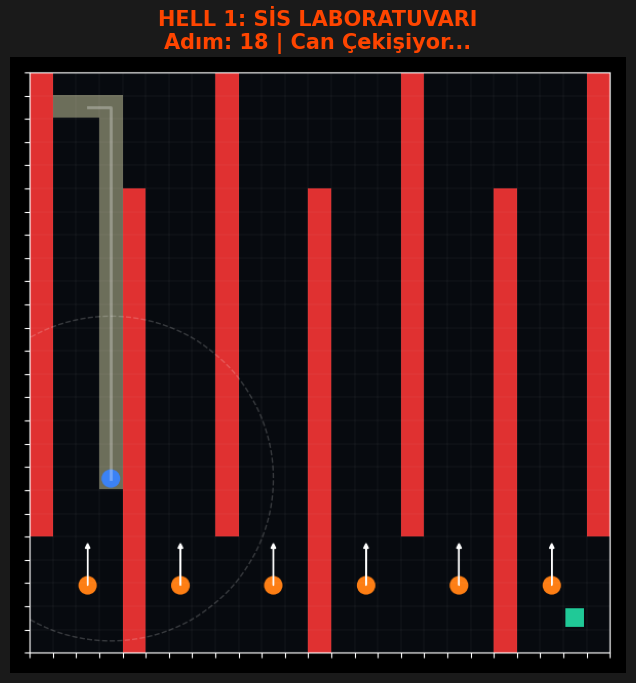

KeyboardInterrupt: 

In [ ]:
class HellGateEnv(AutonomousDriverEnv):
    def __init__(self, level=1, render_mode="rgb_array"):
        self.level = level
        # Cehennem haritaları için grid boyutunu 25x25'e çıkarıyoruz
        super().__init__(grid_size=25, n_static=0, n_dynamic=0, max_steps=500, view_radius=7, render_mode=render_mode)

    def reset(self, seed=None, options=None):
        super(AutonomousDriverEnv, self).reset(seed=seed)
        self.static_obs = set()
        self.dynamic_obs = []

        # ==========================================
        # HELL 1: SİS LABORATUVARI (THE MIST)
        # Konsept: Her yer kapalı, sadece zikzaklı dar geçitler var.
        # ==========================================
        if self.level == 5:
            self.map_type_current = "HELL 1: SİS LABORATUVARI"
            self.agent_pos, self.goal_pos = (1, 1), (23, 23)
            for i in range(0, 25, 4):
                if (i // 4) % 2 == 0:
                    for y in range(0, 20): self.static_obs.add((i, y))
                else:
                    for y in range(5, 25): self.static_obs.add((i, y))
            # Dar geçitlerde bekleyen hızlı nöbetçiler
            for i in range(4, 25, 4):
                self.dynamic_obs.append(DynamicObstacle(x=i-2, y=12, vx=0, vy=0.8, grid_size=self.grid_size))

        # ==========================================
        # HELL 2: MERMİ CEHENNEMİ (BULLET HELL)
        # Konsept: Hiç duvar yok ama 30 tane mermi her yönden geliyor.
        # ==========================================
        elif self.level == 2:
            self.map_type_current = "HELL 2: MERMİ CEHENNEMİ"
            self.agent_pos, self.goal_pos = (2, 2), (22, 22)
            for _ in range(35):
                vx = random.choice([-0.7, 0.7, 0, 1.0, -1.0])
                vy = random.choice([-0.7, 0.7, 0]) if vx == 0 else 0
                self.dynamic_obs.append(DynamicObstacle(x=random.randint(5,20), y=random.randint(5,20), vx=vx, vy=vy, grid_size=self.grid_size))

        # ==========================================
        # HELL 3: KLASİK LABİRENT KABUSU (MAZE FROM HELL)
        # Konsept: 1 birimlik yollar, aşırı uzun çıkmaz sokaklar.
        # ==========================================
        elif self.level == 3:
            self.map_type_current = "HELL 3: LABİRENT KABUSU"
            self.agent_pos, self.goal_pos = (1, 1), (23, 1)
            # Karmaşık bir labirent yapısı
            for x in range(0, 25, 2):
                for y in range(0, 25): self.static_obs.add((x, y))
            for x in range(0, 25, 2):
                gap = random.randint(0, 24)
                if (x//2) % 2 == 0: self.static_obs.remove((x, 0))
                else: self.static_obs.remove((x, 24))
            # Labirentin içinde rastgele dolaşan hayaletler
            for _ in range(8):
                self.dynamic_obs.append(DynamicObstacle(x=random.randint(1,23), y=random.randint(1,23), vx=0.4, vy=0.4, grid_size=self.grid_size))

        # ==========================================
        # HELL 4: DARALAN ÇEMBER (THE FUNNEL)
        # Konsept: Yol sürekli daralıyor ve sonunda tek bir karelik geçit var.
        # ==========================================
        elif self.level == 4:
            self.map_type_current = "HELL 4: DARALAN ÇEMBER"
            self.agent_pos, self.goal_pos = (1, 12), (23, 12)
            for x in range(5, 20):
                for y in range(0, 10): self.static_obs.add((x, y))
                for y in range(15, 25): self.static_obs.add((x, y))
            # Çıkış kapısında 3 tane engel git-gel yapıyor
            for i in range(1):
                self.dynamic_obs.append(DynamicObstacle(x=20, y=10, vx=0, vy=0.6, grid_size=self.grid_size))
                self.dynamic_obs.append(DynamicObstacle(x=20, y=14, vx=0, vy=-0.6, grid_size=self.grid_size))

        # ==========================================
        # HELL 5: SON DURAK (THE MEAT GRINDER)
        # Konsept: İstanbul trafiği + Labirent + Mermi Yağmuru
        # ==========================================
        elif self.level == 1:
            self.map_type_current = "HELL 5: SON DURAK (FİNAL)"
            self.agent_pos, self.goal_pos = (1, 1), (23, 23)
            # Rastgele ama çok yoğun duvarlar
            for _ in range(150):
                self.static_obs.add((random.randint(2, 22), random.randint(2, 22)))
            # 20 tane süper hızlı engel
            for _ in range(20):
                self.dynamic_obs.append(DynamicObstacle(x=random.randint(1,23), y=random.randint(1,23), vx=0.9, vy=0, grid_size=self.grid_size))

        # Bellek Ayarları
        self.visit_map = np.zeros((self.grid_size, self.grid_size), dtype=np.float32)
        self.visit_map[self.agent_pos[0], self.agent_pos[1]] += 1
        self.action_history = deque([[0.0]*5 for _ in range(8)], maxlen=8)
        self.steps = 0
        self.prev_dist = math.hypot(self.agent_pos[0]-self.goal_pos[0], self.agent_pos[1]-self.goal_pos[1])

        info = {"map_type": self.map_type_current}
        return self._get_obs(), info

# --- CEHENNEM SİMÜLASYONUNU BAŞLAT ---
def start_hell_tour(model_path):
    model = PPO.load(model_path)

    for lvl in range(1, 6):
        env = HellGateEnv(level=lvl, render_mode="rgb_array")
        obs, _ = env.reset()
        done = False

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            img = env.render()
            clear_output(wait=True)
            plt.figure(figsize=(8,8))
            plt.imshow(img)
            plt.axis('off')

            durum = 'CEHENNEMDEN ÇIKTI! 🔥🏃' if info.get("is_success", False) else ('YANDI 💀' if terminated else 'Can Çekişiyor...')
            plt.title(f"{env.map_type_current}\nAdım: {env.steps} | {durum}", fontsize=15, fontweight='bold', color='#ff4500')
            plt.gcf().patch.set_facecolor('#1a1a1a')
            plt.show()
            time.sleep(0.04)

        time.sleep(2)

# ÇALIŞTIR
start_hell_tour("/content/autonomous_driver/ppo_stage_4_hardcore")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128165 (\N{COLLISION SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


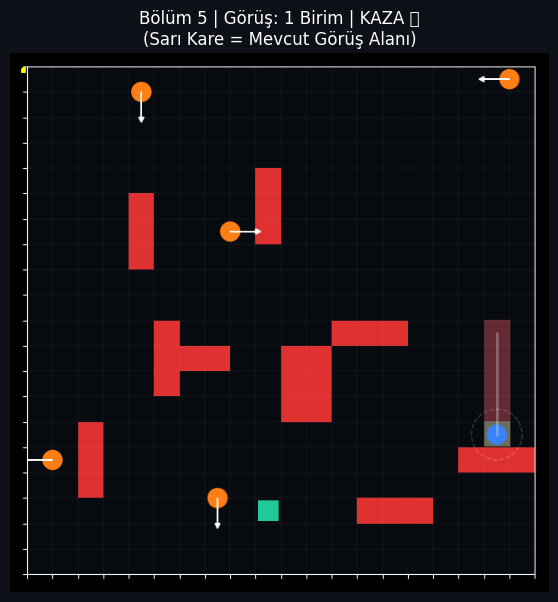

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from stable_baselines3 import PPO

def test_blind_agent(model_path, n_episodes=5):
    # Görüşü 1 birime düşürüyoruz
    # Not: Model yine 102 veri bekliyor ama biz ona sadece 1 birimlik mesafe verisi besleyeceğiz
    env_config = {
        "grid_size": 20,
        "n_static": 30,
        "n_dynamic": 5,
        "max_steps": 200,
        "view_radius": 1  # İŞTE O KRİTİK DEĞİŞİKLİK!
    }

    env = AutonomousDriverEnv(**env_config, render_mode="rgb_array")
    model = PPO.load(model_path)

    print(f"🔦 KÖR SÜRÜŞ TESTİ: Görüş Mesafesi {env_config['view_radius']} Birim!")
    time.sleep(2)

    for ep in range(n_episodes):
        obs, _ = env.reset()
        done = False

        while not done:
            # Model 7 birimlik eğitimle 1 birimlik veriyi yorumlamaya çalışıyor
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            img = env.render()
            clear_output(wait=True)

            plt.figure(figsize=(7,7))
            plt.imshow(img)

            # Görüş alanını görsel olarak simüle edelim (Ajanın etrafındaki 1 birimlik kare)
            ax = plt.gca()
            rect = plt.Rectangle((env.agent_pos[1]-1.5, env.agent_pos[0]-1.5), 3, 3,
                                 linewidth=2, edgecolor='yellow', facecolor='none', linestyle='--')
            ax.add_patch(rect)

            status = "BAŞARDI (NASIL OLDUYSA?!) 🎉" if info.get("is_success", False) else ("KAZA 💥" if terminated else "Körlemesine Gidiyor...")
            plt.title(f"Bölüm {ep+1} | Görüş: 1 Birim | {status}\n(Sarı Kare = Mevcut Görüş Alanı)", color='white')
            plt.axis('off')
            plt.gcf().patch.set_facecolor('#0d1117')
            plt.show()

            time.sleep(0.1)

        time.sleep(1.5)

# ÇALIŞTIR
model_yolu = "/content/autonomous_driver/ppo_stage_4_hardcore"
test_blind_agent(model_yolu)

In [ ]:
import time
from IPython.display import clear_output
import matplotlib.pyplot as plt

def run_25_map_gauntlet(model_path):
    model = PPO.load(model_path)

    print("🚀 25 HARİTALIK HIZLI SİMÜLASYON BAŞLIYOR!")
    print("Kurallar: Maksimum 200 adım. Bitiremeyen elenir, diğer haritaya geçilir!")
    time.sleep(2)

    basari_sayisi = 0
    kaza_sayisi = 0
    zaman_asimi_sayisi = 0

    for level in range(1, 26):
        # Her levelda zorluk dinamik olarak biraz artar
        n_stat = 20 + level             # Giderek kalabalıklaşan duvarlar
        n_dyn = 4 + (level // 4)        # Giderek artan trafik

        env_config = {
            "grid_size": 20,
            "n_static": n_stat,
            "n_dynamic": n_dyn,
            "max_steps": 200,           # 200 ADIM SINIRI BURADA!
            "view_radius": 7
        }

        # Zaten tanımlı olan ortamımızı kullanıyoruz
        env = AutonomousDriverEnv(**env_config, render_mode="rgb_array")
        obs, _ = env.reset()
        done = False

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            # Eğer 200 adıma ulaşırsa 'truncated' otomatik olarak True döner
            done = terminated or truncated

            img = env.render()
            clear_output(wait=True)
            plt.figure(figsize=(7, 7))
            plt.imshow(img)
            plt.axis('off')

            # Üst Bilgi Çubuğunu Güncelle
            if info.get("is_success", False):
                durum = "BAŞARILI! 🎉"
            elif terminated:
                durum = "KAZA YAPTI 💥"
            elif truncated:
                durum = "SÜRE BİTTİ ⏳ (Atlanıyor)"
            else:
                durum = f"Adım: {env.steps} / 200"

            plt.title(f"Harita {level}/25 | {env.map_type_current.upper()}\n{durum}",
                      fontsize=14, fontweight='bold', color='white')

            # Arka plan rengini koyu temaya uygun yapalım
            plt.gcf().patch.set_facecolor('#0d1117')
            plt.show()

            # Animasyon hızını biraz artırdım ki 25 harita çok uzun sürmesin
            time.sleep(0.05)

        # İstatistikleri Kaydet
        if info.get("is_success", False):
            basari_sayisi += 1
        elif terminated:
            kaza_sayisi += 1
        elif truncated:
            zaman_asimi_sayisi += 1

        # Sonucu görmek için 1.5 saniye ekranda beklet ve diğer haritaya geç
        time.sleep(1.5)

    # 25 Harita Sonrası Nihai Rapor
    clear_output(wait=True)
    print("="*40)
    print("🏁 25 HARİTALIK SİMÜLASYON TAMAMLANDI 🏁")
    print("="*40)
    print(f"🏆 Başarılı Tamamlama : {basari_sayisi}")
    print(f"💥 Kaza Yaparak Ölme  : {kaza_sayisi}")
    print(f"⏳ Zaman Aşımı (200)  : {zaman_asimi_sayisi}")
    print("="*40)

# -----------------------------------------
# SİMÜLASYONU BAŞLAT
# -----------------------------------------
model_yolu = "/content/autonomous_driver/ppo_stage_4_hardcore"
run_25_map_gauntlet(model_path=model_yolu)

🏁 25 HARİTALIK SİMÜLASYON TAMAMLANDI 🏁
🏆 Başarılı Tamamlama : 19
💥 Kaza Yaparak Ölme  : 6
⏳ Zaman Aşımı (200)  : 0


In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# ==========================================
# 1. 100x100 İSTANBUL HARİTASI ÜRETİMİ
# ==========================================
def create_istanbul_map():
    # 0: Yol/Boşluk, 1: Normal Bina (Gri), 2: Tarihi Eser/Cami (Altın),
    # 3: Surlar (Kırmızı), 4: Boğaz Suyu Sınırı (Mavi)
    grid = np.zeros((100, 100), dtype=int)

    # Dış Sınırlar (Surlar)
    grid[0, :] = 3; grid[99, :] = 3
    grid[:, 0] = 3; grid[:, 99] = 3

    # Boğaziçi (Ortadan çapraz geçen su yolu - duvar gibi modelledik ki içinden geçilmesin)
    for i in range(100):
        for j in range(100):
            if abs(i - j) < 4:  # Çapraz boğaz hattı
                grid[i, j] = 4

    # Boğaz Köprüsü (Geçiş noktası açalım)
    for i in range(48, 53):
        for j in range(48, 53):
            grid[i, j] = 0

    # Tarihi Yarımada (Sol Alt Kısım) - Bolca Tarihi Eser ve dar sokaklar
    for i in range(10, 40, 3):
        for j in range(10, 40, 3):
            if grid[i, j] == 0:
                grid[i, j] = np.random.choice([1, 1, 2]) # Çoğunluk bina, bazısı tarihi

    # Ayasofya ve Sultanahmet Sembolik (Büyük altın bloklar)
    grid[20:23, 20:23] = 2
    grid[30:33, 15:18] = 2

    # Beyoğlu / Galata (Sağ Üst Kısım) - Sıkışık Binalar
    for i in range(60, 90, 2):
        for j in range(60, 90, 2):
            if grid[i, j] == 0 and np.random.rand() > 0.3:
                grid[i, j] = 1

    # Galata Kulesi (Büyük bir blok)
    grid[70:72, 70:72] = 2

    return grid

# ==========================================
# 2. 3D RAYCASTING MOTORU (DOOM TARZI)
# ==========================================
class Raycaster3D:
    def __init__(self, width=160, height=120):
        self.width = width
        self.height = height

        # Renk Paleti (RGB)
        self.colors = {
            1: [150, 150, 150], # Normal Binalar (Gri)
            2: [255, 215, 0],   # Tarihi Eserler (Altın)
            3: [139, 0, 0],     # Surlar (Koyu Kırmızı)
            4: [30, 144, 255]   # Boğaz (Mavi Su Duvarı)
        }

    def render(self, map_grid, pos_x, pos_y, dir_x, dir_y, plane_x, plane_y):
        # Ekran buffer'ı (Gökyüzü mavi, yer koyu gri)
        buffer = np.zeros((self.height, self.width, 3), dtype=np.uint8)
        buffer[:self.height//2, :] = [135, 206, 235] # Gökyüzü
        buffer[self.height//2:, :] = [50, 50, 50]    # Asfalt

        # Ekrandaki her bir dikey piksel sütunu (ray) için döngü
        for x in range(self.width):
            camera_x = 2 * x / float(self.width) - 1
            ray_dir_x = dir_x + plane_x * camera_x
            ray_dir_y = dir_y + plane_y * camera_x

            map_x = int(pos_x)
            map_y = int(pos_y)

            delta_dist_x = abs(1 / ray_dir_x) if ray_dir_x != 0 else 1e30
            delta_dist_y = abs(1 / ray_dir_y) if ray_dir_y != 0 else 1e30

            hit = 0
            side = 0

            # Işın yönüne göre adım hesaplama (DDA Algoritması)
            if ray_dir_x < 0:
                step_x = -1
                side_dist_x = (pos_x - map_x) * delta_dist_x
            else:
                step_x = 1
                side_dist_x = (map_x + 1.0 - pos_x) * delta_dist_x

            if ray_dir_y < 0:
                step_y = -1
                side_dist_y = (pos_y - map_y) * delta_dist_y
            else:
                step_y = 1
                side_dist_y = (map_y + 1.0 - pos_y) * delta_dist_y

            # Işını duvara çarpana kadar fırlat
            while hit == 0:
                if side_dist_x < side_dist_y:
                    side_dist_x += delta_dist_x
                    map_x += step_x
                    side = 0
                else:
                    side_dist_y += delta_dist_y
                    map_y += step_y
                    side = 1

                if map_grid[map_x, map_y] > 0:
                    hit = 1

            # Balıkgözü (Fisheye) efektini önlemek için dik mesafe
            if side == 0: perp_wall_dist = (map_x - pos_x + (1 - step_x) / 2) / ray_dir_x
            else:         perp_wall_dist = (map_y - pos_y + (1 - step_y) / 2) / ray_dir_y

            if perp_wall_dist <= 0: perp_wall_dist = 0.1

            # Çizilecek çizginin yüksekliği (Uzaktakiler kısa, yakındakiler uzun)
            line_height = int(self.height / perp_wall_dist)

            draw_start = -line_height // 2 + self.height // 2
            draw_start = max(0, draw_start)

            draw_end = line_height // 2 + self.height // 2
            draw_end = min(self.height - 1, draw_end)

            # Duvar rengini al ve gölgelendirme yap (3D hissini artırır)
            color = self.colors.get(map_grid[map_x, map_y], [255, 255, 255]).copy()
            if side == 1:
                color = [int(c * 0.7) for c in color] # Y eksenindeki duvarları koyulaştır

            buffer[draw_start:draw_end, x] = color

        return buffer

# ==========================================
# 3. İSTANBUL TURU (SİMÜLASYONU ÇALIŞTIRMA)
# ==========================================
def tour_istanbul_3d():
    print("3D İstanbul Simülasyonu Yükleniyor...")
    istanbul_map = create_istanbul_map()
    renderer = Raycaster3D(width=160, height=120) # Colab'da hızlı aksın diye çözünürlük

    # Ajan Başlangıç Durumu (Tarihi yarımadada, köprüye bakıyor)
    pos_x, pos_y = 5.0, 5.0
    dir_x, dir_y = 1.0, 1.0

    # Kamera Düzlemi (FOV - Görüş Açısı: ~66 derece)
    plane_x, plane_y = -0.66, 0.66

    # 50 Karelik Kısa Bir Sinematik Tur
    for frame in range(100):
        # Kamerayı her karede hafifçe sağa döndür
        rot_speed = 0.05
        old_dir_x = dir_x
        dir_x = dir_x * math.cos(rot_speed) - dir_y * math.sin(rot_speed)
        dir_y = old_dir_x * math.sin(rot_speed) + dir_y * math.cos(rot_speed)

        old_plane_x = plane_x
        plane_x = plane_x * math.cos(rot_speed) - plane_y * math.sin(rot_speed)
        plane_y = old_plane_x * math.sin(rot_speed) + plane_y * math.cos(rot_speed)

        # İleri doğru hareket et (Çarpışma kontrolü)
        move_speed = 0.3
        new_x = pos_x + dir_x * move_speed
        new_y = pos_y + dir_y * move_speed

        if istanbul_map[int(new_x), int(pos_y)] == 0: pos_x = new_x
        if istanbul_map[int(pos_x), int(new_y)] == 0: pos_y = new_y

        # Render ve Çizim
        img_3d = renderer.render(istanbul_map, pos_x, pos_y, dir_x, dir_y, plane_x, plane_y)

        clear_output(wait=True)
        plt.figure(figsize=(10, 6))

        # 3D Görüntü
        plt.subplot(1, 2, 1)
        plt.imshow(img_3d)
        plt.title("Ajanın Gözünden (POV 3D)", color='white', fontweight='bold')
        plt.axis('off')

        # 2D Harita ve Ajanın Konumu
        plt.subplot(1, 2, 2)
        plt.imshow(istanbul_map, cmap='magma')
        plt.plot(pos_y, pos_x, 'go', markersize=10) # Ajan Yeşil Nokta (Matplotlib XY tersliği için pos_y, pos_x)
        # Baktığı yönü çiz
        plt.plot([pos_y, pos_y + dir_y*3], [pos_x, pos_x + dir_x*3], 'g-', linewidth=2)
        plt.title("Beynin Gördüğü (2D Izgara)", color='white', fontweight='bold')
        plt.axis('off')

        plt.gcf().patch.set_facecolor('#0d1117')
        plt.tight_layout()
        plt.show()

# 🎬 Başlat
tour_istanbul_3d()

KeyboardInterrupt: 